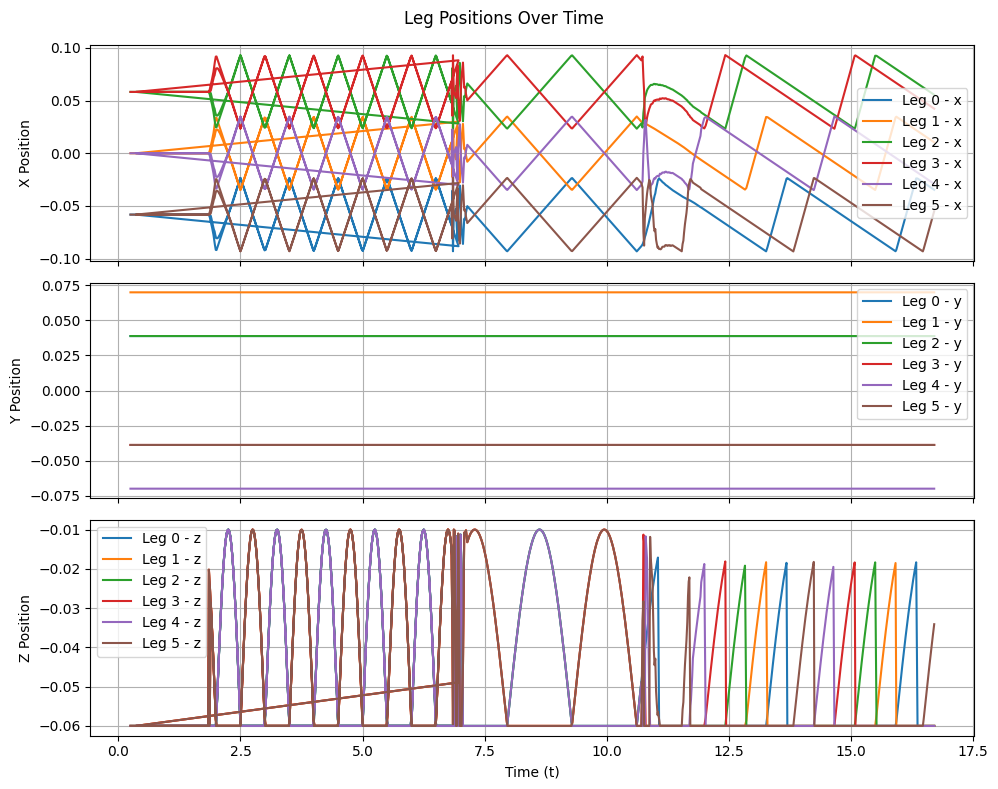

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('leg_pos.csv', names=['t', 'leg_index', 'x', 'y', 'z'], header=None)

# Plot the data for each leg (x, y, z over time)
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot x, y, and z positions
for leg_index in range(6):  # Iterate over all 6 legs
    leg_data = df[df['leg_index'] == leg_index]
    
    # Plot x position vs time
    axes[0].plot(leg_data['t'], leg_data['x'], label=f'Leg {leg_index} - x')
    
    # Plot y position vs time
    axes[1].plot(leg_data['t'], leg_data['y'], label=f'Leg {leg_index} - y')
    
    # Plot z position vs time
    axes[2].plot(leg_data['t'], leg_data['z'], label=f'Leg {leg_index} - z')

# Set labels and titles
axes[0].set_ylabel('X Position')
axes[1].set_ylabel('Y Position')
axes[2].set_ylabel('Z Position')
axes[2].set_xlabel('Time (t)')

# Add a title and grid
fig.suptitle('Leg Positions Over Time')
for ax in axes:
    ax.grid(True)

# Add a legend
axes[0].legend()
axes[1].legend()
axes[2].legend()

# Show the plot
plt.tight_layout()
plt.show()


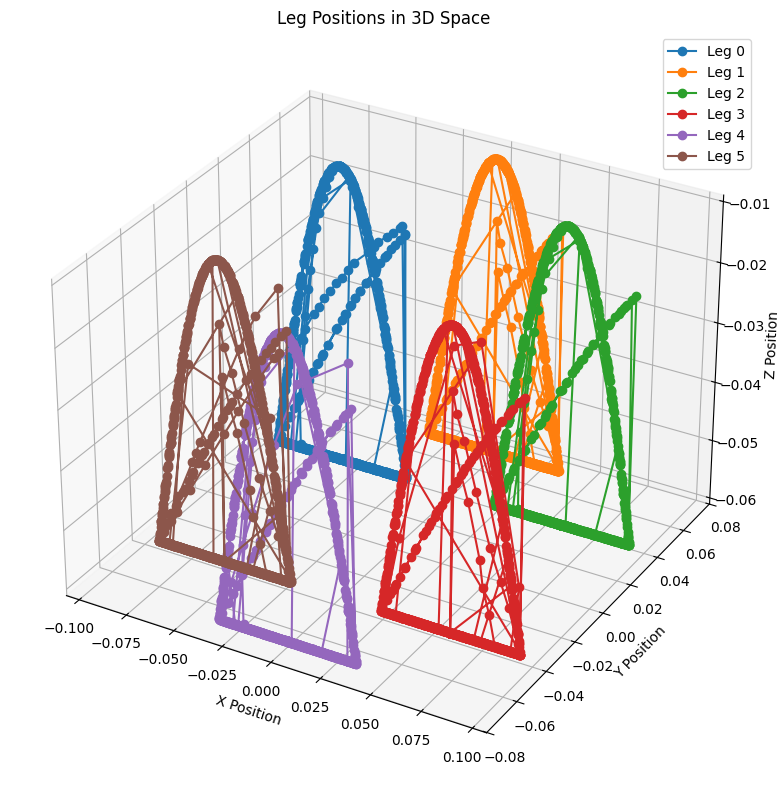

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('leg_pos.csv', names=['t', 'leg_index', 'x', 'y', 'z'], header=None)

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot x, y, and z positions for each leg
for leg_index in range(6):  # Iterate over all 6 legs
    leg_data = df[df['leg_index'] == leg_index]
    
    # Plot x, y, z positions vs time in 3D space
    ax.plot(leg_data['x'], leg_data['y'], leg_data['z'], label=f'Leg {leg_index}', marker='o')

# Set labels and title
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.set_title('Leg Positions in 3D Space')

# Add a legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [1]:
import numpy as np
import random

# Parameter Q-learning
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor
epsilon = 0.1  # Exploration rate

# Definisi state (kemiringan IMU dalam derajat)
states = [-15, -10, -5, 0, 5, 10, 15]  # Misalnya, dari -15° (miring ke belakang) sampai 15° (miring ke depan)

# Definisi aksi
actions = ["maju", "naik_badan", "mundur"]

# Inisialisasi Q-table (ukuran: jumlah state x jumlah aksi)
Q_table = np.zeros((len(states), len(actions)))

def get_state_index(angle):
    """Mencari indeks state terdekat dalam daftar states"""
    return min(range(len(states)), key=lambda i: abs(states[i] - angle))

def choose_action(state_idx):
    """Memilih aksi berdasarkan Q-table (eksploitasi vs eksplorasi)"""
    if random.uniform(0, 1) < epsilon:  
        return random.randint(0, len(actions) - 1)  # Eksplorasi (pilih aksi acak)
    return np.argmax(Q_table[state_idx])  # Eksploitasi (pilih aksi terbaik dari Q-table)

def get_reward(angle):
    """Menentukan reward berdasarkan kemiringan robot"""
    if abs(angle) < 5:  # Jika robot hampir datar
        return 1  # Reward positif (stabil)
    return -1  # Reward negatif (tidak stabil)

# Simulasi pembelajaran
for episode in range(1000):  # Jalankan 1000 episode
    imu_angle = random.choice(states)  # Simulasi bacaan IMU acak (misalnya dari sensor nyata)
    state_idx = get_state_index(imu_angle)

    action_idx = choose_action(state_idx)
    action = actions[action_idx]

    # Simulasi perubahan sudut setelah aksi
    if action == "maju":
        new_angle = imu_angle - 2  # Robot cenderung miring ke depan
    elif action == "naik_badan":
        new_angle = imu_angle * 0.8  # Robot lebih stabil
    elif action == "mundur":
        new_angle = imu_angle + 2  # Robot cenderung miring ke belakang
    else:
        new_angle = imu_angle

    # Dapatkan reward dari kondisi baru
    new_state_idx = get_state_index(new_angle)
    reward = get_reward(new_angle)

    # Update Q-table
    Q_table[state_idx, action_idx] = Q_table[state_idx, action_idx] + alpha * (
        reward + gamma * np.max(Q_table[new_state_idx]) - Q_table[state_idx, action_idx]
    )

# Cetak Q-table hasil belajar
print("Q-table setelah training:")
print(Q_table)


Q-table setelah training:
[[-3.94819977 -3.95912839 -3.93080415]
 [-3.87599132 -3.88831745 -3.92921434]
 [ 0.72293912  7.3463375   2.64494216]
 [ 7.06577278  2.25338351  2.68661799]
 [ 7.89401554  1.9314813   1.69114828]
 [-3.48385922 -3.42604166 -3.44236287]
 [-3.68075344 -3.64085346 -3.69506844]]
